# Loan Default Prediction - Part 1: Cleaning Data and Looking at Charts

## What is this project about?
When people ask for a loan, banks want to know if they will pay it back. If they do not pay it back, it is called a "default". This is bad for banks because they lose money. In this project, we want to predict if a person is likely to default on their loan or not.

In this first notebook, we will do four simple things:
1. **Look at our raw data**: See what information we have and check for any missing spots.
2. **Fill in missing data**: If some rows have blank spots, we will fill them in with smart guesses (called "imputation").
3. **Make charts (EDA)**: Create easy graphs to see how things like income, education, and credit history affect whether a loan gets approved.
4. **Create new columns**: Mix some columns together to make it easier for our models to learn.

## 2. Load and Look at the Data
First, we will load our dataset using `pandas` and print out the first few rows to see what it looks like.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load the dataset
df = pd.read_csv('loan_data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001000,Male,No,3+,Graduate,NaN,7268,300,157.0,360.0,1.0,Rural,Y
1,LP001001,Female,No,0,Graduate,No,11189,0,212.0,360.0,1.0,Semiurban,Y
2,LP001002,Male,Yes,2,Not Graduate,No,2267,0,47.0,180.0,1.0,Urban,N
3,LP001003,Male,Yes,0,Graduate,No,2564,0,67.0,360.0,1.0,Semiurban,Y
4,LP001004,Male,No,0,Graduate,No,8189,890,230.0,360.0,1.0,Urban,N


In [2]:
# Print dataset dimensions and check structure
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            608 non-null    object 
 3   Dependents         591 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      590 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         589 non-null    float64
 9   Loan_Amount_Term   601 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 62.5+ KB


## 3. Filling in the Missing Blanks (Imputation)

Sometimes, people forget to fill out some parts of their loan application, so we have empty spaces in our data. We cannot feed empty spaces to our computer model, so we must fill them in:
- For **category columns** (like Gender, Married, Dependents, Self_Employed, Credit_History), we will fill blanks with the **most common value** (the "Mode").
- For **number columns** (like LoanAmount, Loan_Amount_Term), we will fill blanks with the **middle value** (the "Median") so big outliers do not pull our average too far.

In [3]:
# Inspect missing values before imputation
missing_stats = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_stats[missing_stats['Missing Count'] > 0]

,Missing Count,Percentage (%)
Gender,16,2.61
Married,6,0.98
Dependents,23,3.75
Self_Employed,24,3.91
LoanAmount,25,4.07
Loan_Amount_Term,13,2.12
Credit_History,50,8.14


In [4]:
# Impute categorical features with their Mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# Impute continuous features with their Median
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Verify that no missing values remain
print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


## 4. Making Easy Charts (EDA)

Now, let's make some simple graphs to find patterns in our data. This helps us see how different features affect our loan approvals.

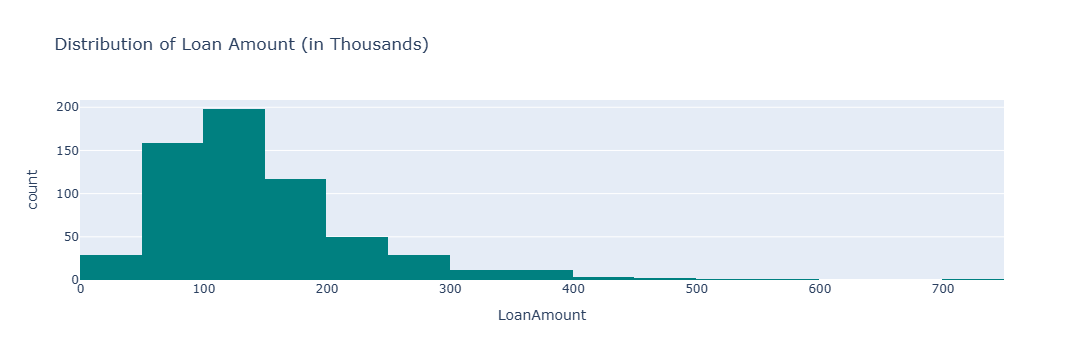

In [5]:
# 4.1 Distribution of Loan Amount
fig = px.histogram(df, x='LoanAmount', title='Distribution of Loan Amount (in Thousands)', nbins=30, color_discrete_sequence=['teal'])
fig.show()

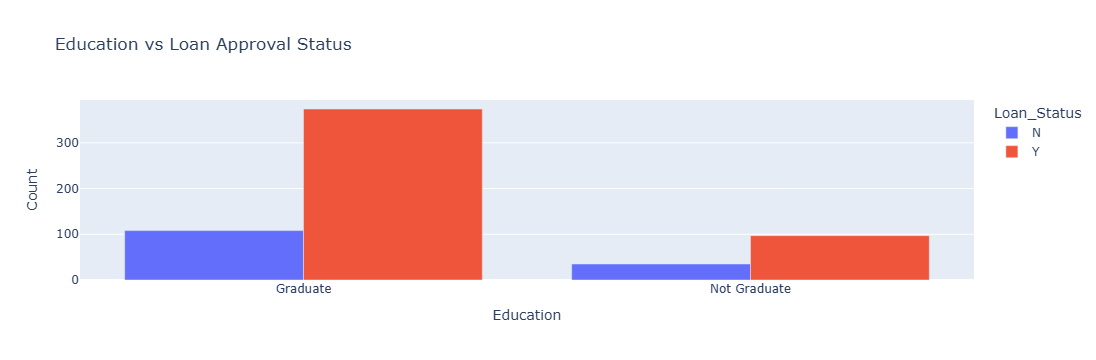

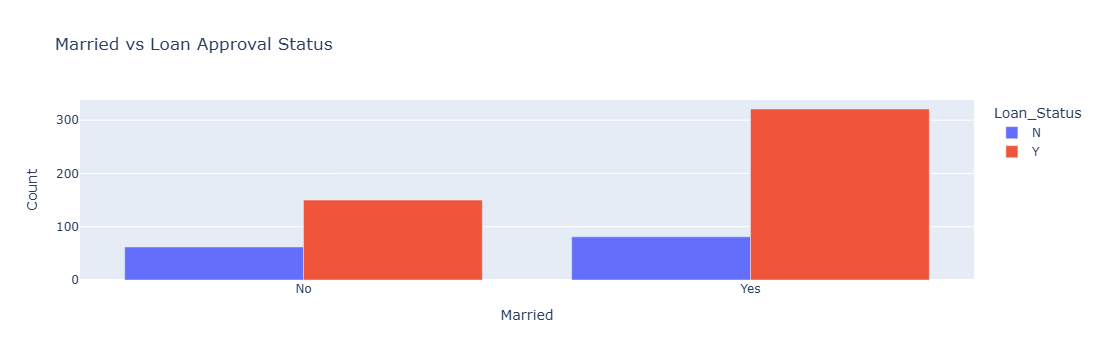

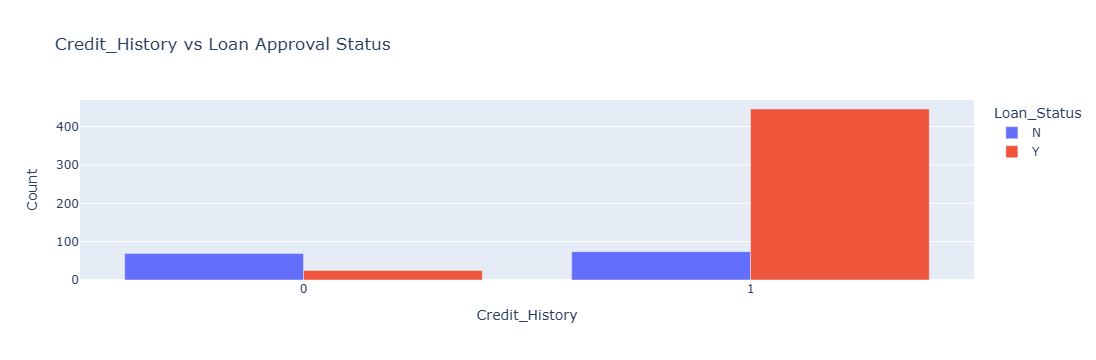

In [6]:
# 4.2 Bivariate visualizations: Categoricals vs Loan_Status
for col in ['Education', 'Married', 'Credit_History']:
    fig = px.bar(df.groupby([col, 'Loan_Status']).size().reset_index(name='Count'), x=col, y='Count', color='Loan_Status', barmode='group', title=f'{col} vs Loan Approval Status')
    fig.show()

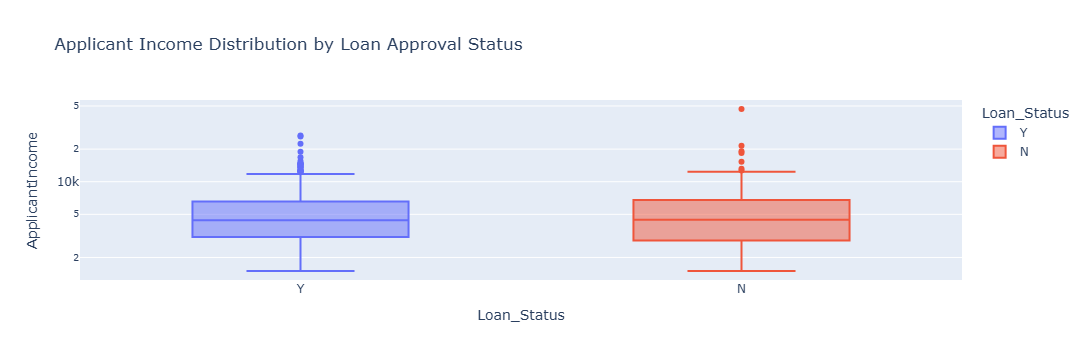

In [7]:
# 4.3 Distribution of Income by Loan_Status
fig = px.box(df, x='Loan_Status', y='ApplicantIncome', color='Loan_Status', title='Applicant Income Distribution by Loan Approval Status', log_y=True)
fig.show()

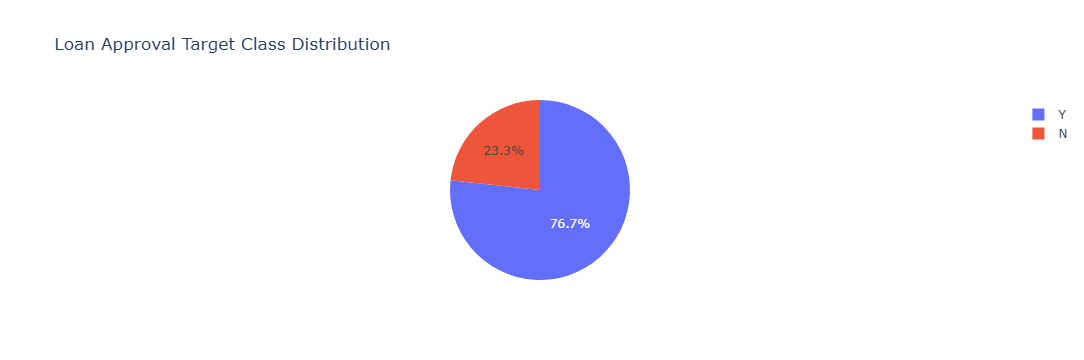

Loan Status Proportions:
Loan_Status
Y    76.7
N    23.3
Name: proportion, dtype: float64


In [8]:
# 4.4 Class Imbalance Check of Target Feature
fig = px.pie(df, names='Loan_Status', title='Loan Approval Target Class Distribution')
fig.show()

print("Loan Status Proportions:")
print(df['Loan_Status'].value_counts(normalize=True).round(3) * 100)

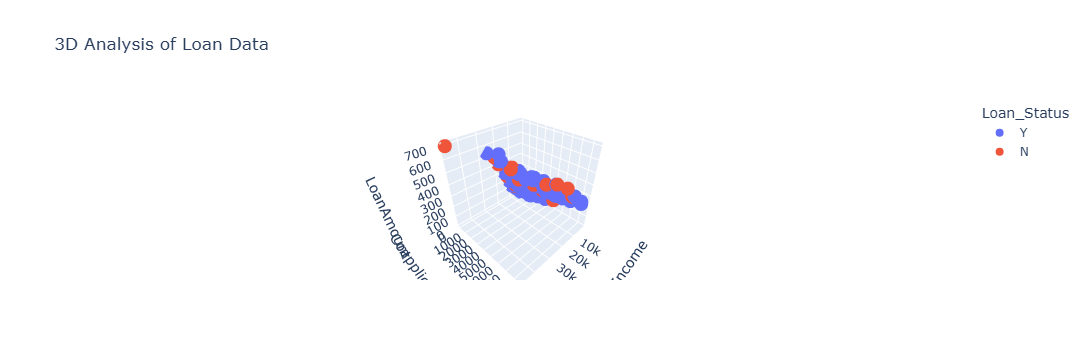

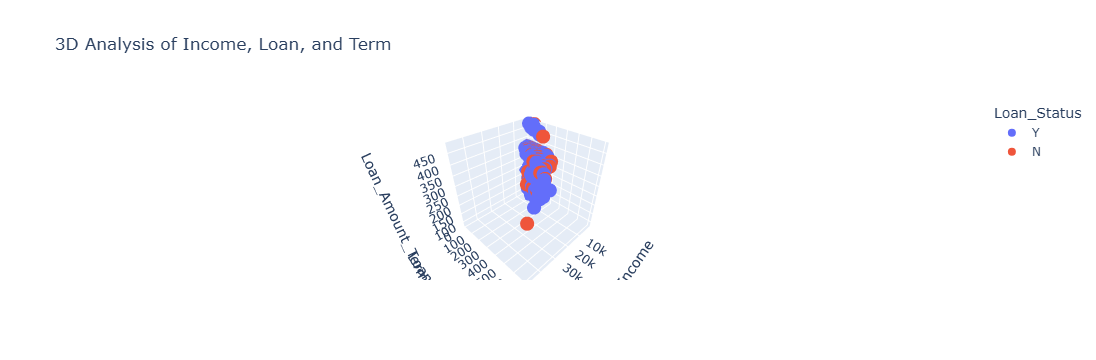

In [10]:
# 4.5 3D Visualization
fig = px.scatter_3d(df, x='ApplicantIncome', y='CoapplicantIncome', z='LoanAmount', color='Loan_Status', title='3D Analysis of Loan Data')
fig.show()

# Another 3D plot
fig2 = px.scatter_3d(df, x='ApplicantIncome', y='LoanAmount', z='Loan_Amount_Term', color='Loan_Status', title='3D Analysis of Income, Loan, and Term')
fig2.show()

## 5. Creating Helpful New Columns

Let's create two simple new columns by combining what we already have:
1. **TotalIncome**: Add Applicant Income and Coapplicant Income together to see how much money the whole family makes.
2. **Income_to_Loan_Ratio**: Divide the total income by the loan amount to see if they make enough money to pay back the loan easily.

In [11]:
# Engineer combined financial metrics
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_to_Loan_Ratio'] = df['TotalIncome'] / (df['LoanAmount'] * 1000 + 1)

df[['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome', 'LoanAmount', 'Income_to_Loan_Ratio']].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,Income_to_Loan_Ratio
0,7268,300,7568,157.0,0.048204
1,11189,0,11189,212.0,0.052778
2,2267,0,2267,47.0,0.048233
3,2564,0,2564,67.0,0.038268
4,8189,890,9079,230.0,0.039474


## 6. Save our Cleaned Data

Our data is now clean, has no empty spaces, and is ready for the machine learning model. We will save it as a new file called `loan_data_cleaned.csv` so our next notebook can use it!

In [12]:
# Export clean dataset
cleaned_csv_path = 'loan_data_cleaned.csv'
df.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned dataset saved to {cleaned_csv_path} with shape {df.shape}")

Successfully cleaned and saved dataset to loan_data_cleaned.csv with shape (614, 15)
